In [ ]:
# Cardiovascular Disease Risk Analysis and Prediction

This project analyzes cardiovascular disease risk factors using data analytics and machine learning techniques. The objective is to identify factors associated with cardiovascular disease and build a prediction model.

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [ ]:
# Data Loading

In [47]:
df = pd.read_csv("cardio_train.csv", sep=';')

In [48]:
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [49]:
df.shape

(70000, 13)

In [50]:
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [ ]:
# Data Cleaning

In [51]:
df.isnull().sum()

,0
id,0
age,0
gender,0
height,0
weight,0
ap_hi,0
ap_lo,0
cholesterol,0
gluc,0
smoke,0


In [52]:
df.duplicated().sum()

np.int64(0)

In [53]:
df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [54]:
df.drop_duplicates(inplace=True)

In [55]:
df["age_years"] = (df["age"] / 365).astype(int)

In [56]:
df[["age","age_years"]].head()

,age,age_years
0,18393,50
1,20228,55
2,18857,51
3,17623,48
4,17474,47


In [ ]:
# Feature Engineering

In [57]:
df["BMI"] = df["weight"] / ((df["height"]/100)**2)
df["BMI"].head()

,BMI
0,21.967120
1,34.927679
2,23.507805
3,28.710479
4,23.011177


In [ ]:
# Exploratory Data Analysis

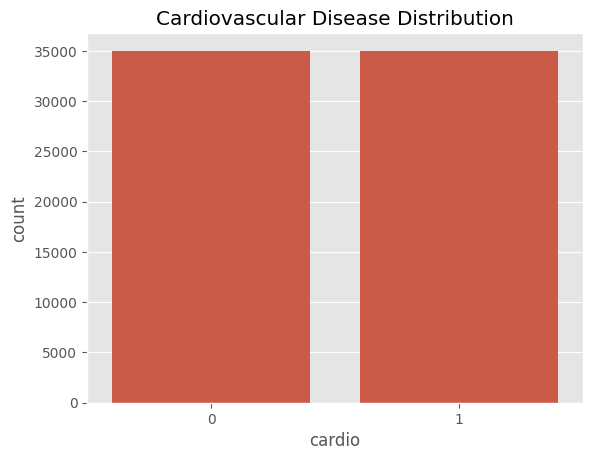

In [58]:
sns.countplot(x="cardio", data=df)

plt.title("Cardiovascular Disease Distribution")

plt.show()

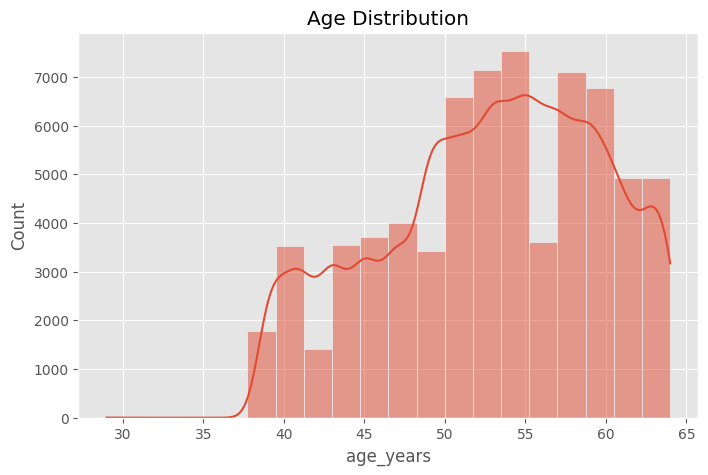

In [59]:
#Age Analysis
plt.figure(figsize=(8,5))

sns.histplot(df["age_years"],
             bins=20,
             kde=True)

plt.title("Age Distribution")

plt.show()


In [92]:
plt.savefig("age_distribution.png")

<Figure size 640x480 with 0 Axes>

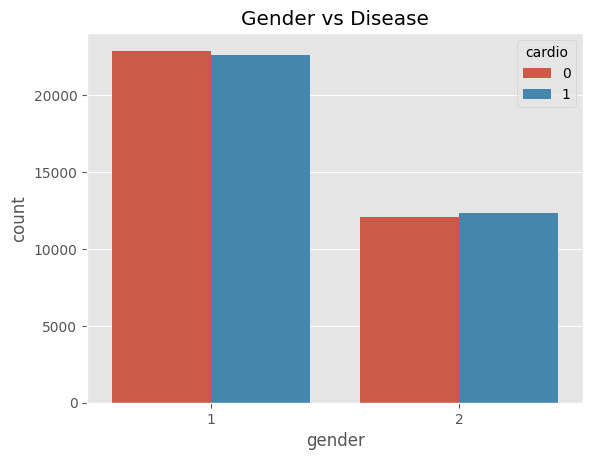

In [60]:
#Gender Analysis
sns.countplot(x="gender",
              hue="cardio",
              data=df)

plt.title("Gender vs Disease")

plt.show()

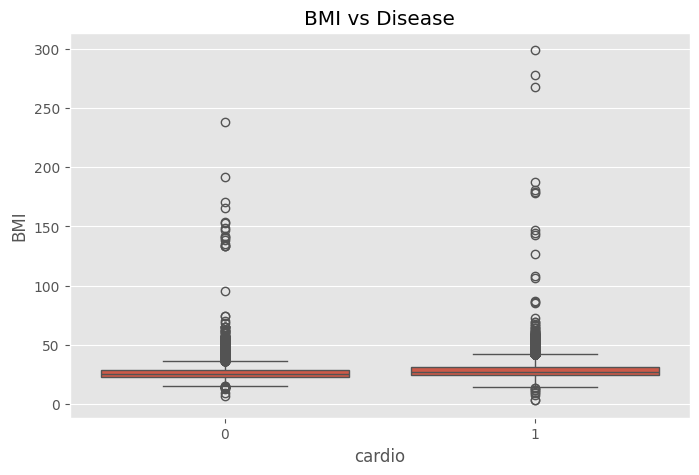

In [61]:
#BMI Analysis
plt.figure(figsize=(8,5))

sns.boxplot(x="cardio",
            y="BMI",
            data=df)

plt.title("BMI vs Disease")

plt.show()

In [91]:
plt.savefig("bmi_vs_disease.png")

<Figure size 640x480 with 0 Axes>

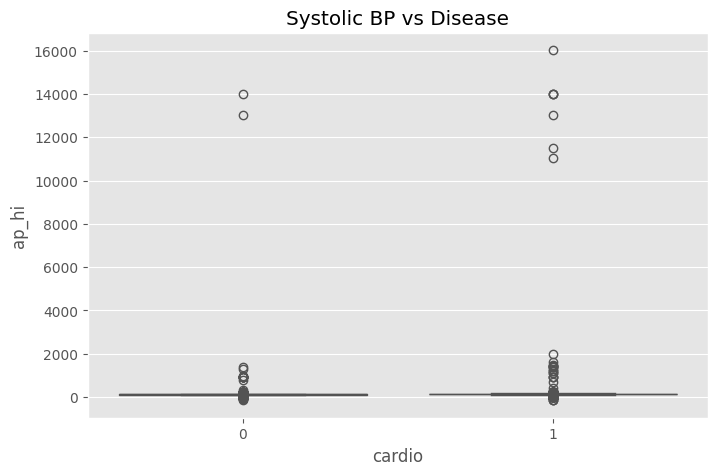

In [62]:
#Blood Pressure Analysis
plt.figure(figsize=(8,5))

sns.boxplot(x="cardio",
            y="ap_hi",
            data=df)

plt.title("Systolic BP vs Disease")

plt.show()

In [90]:
plt.savefig("blood_pressure_analysis.png")

<Figure size 640x480 with 0 Axes>

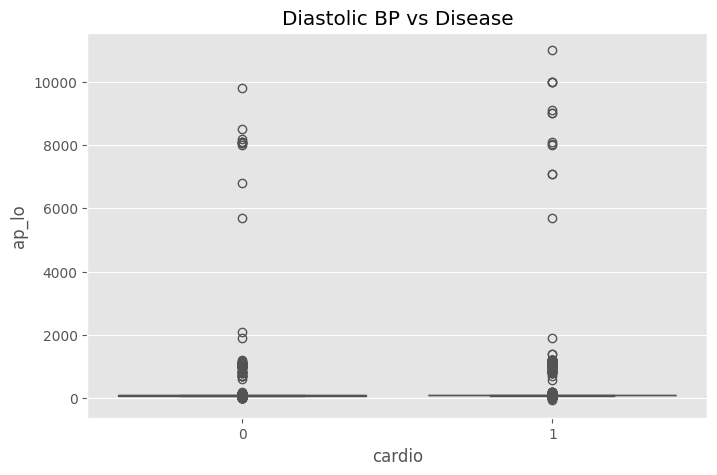

In [63]:
#Diastolic BP
plt.figure(figsize=(8,5))

sns.boxplot(x="cardio",
            y="ap_lo",
            data=df)

plt.title("Diastolic BP vs Disease")

plt.show()

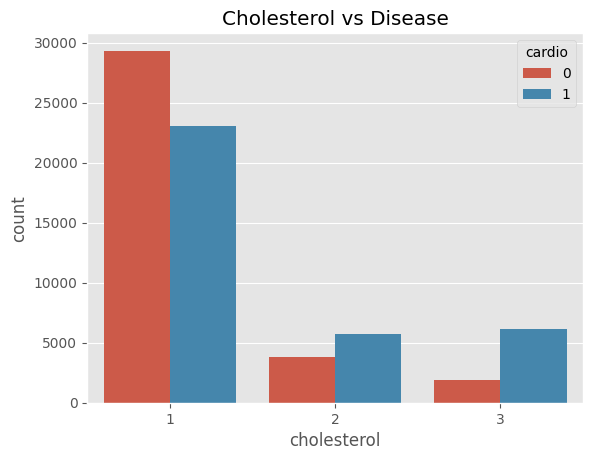

In [64]:
#Cholesterol Analysis
sns.countplot(
    x="cholesterol",
    hue="cardio",
    data=df
)

plt.title("Cholesterol vs Disease")

plt.show()

In [89]:
plt.savefig("cholesterol_analysis.png")

<Figure size 640x480 with 0 Axes>

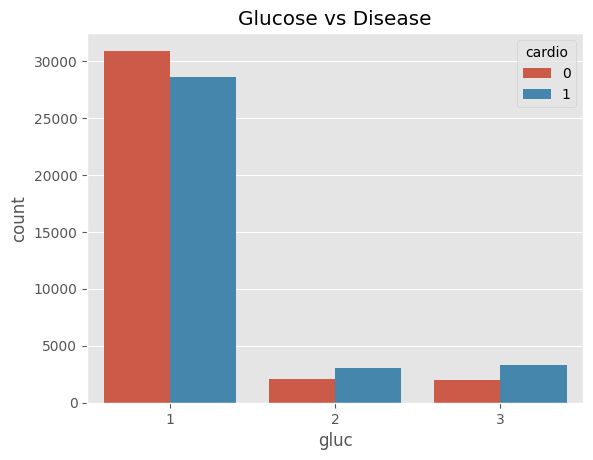

In [65]:
#Glucose Analysis
sns.countplot(
    x="gluc",
    hue="cardio",
    data=df
)

plt.title("Glucose vs Disease")

plt.show()

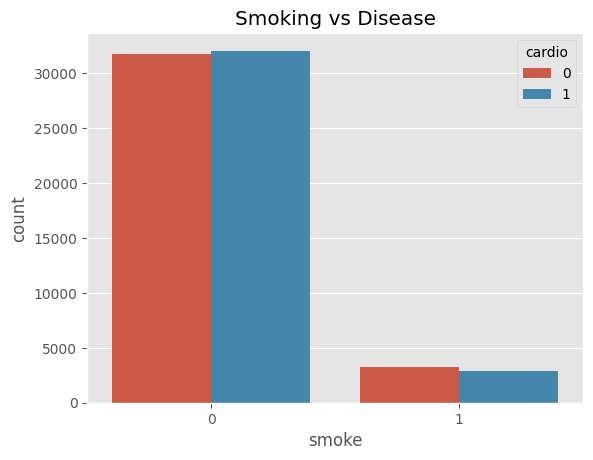

In [66]:
#Smoking Analysis
sns.countplot(
    x="smoke",
    hue="cardio",
    data=df
)

plt.title("Smoking vs Disease")

plt.show()

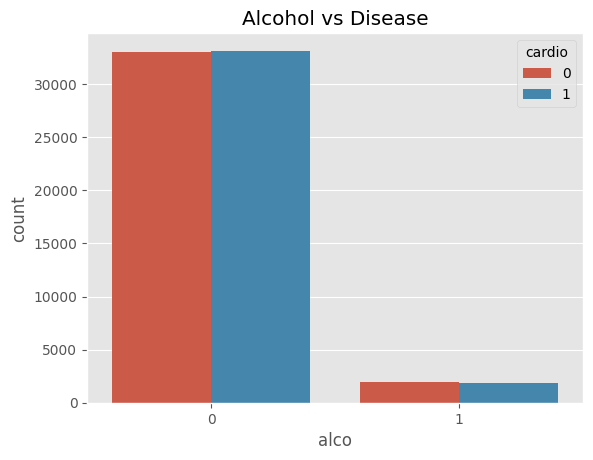

In [67]:
#Alcohol Analysis
sns.countplot(
    x="alco",
    hue="cardio",
    data=df
)

plt.title("Alcohol vs Disease")

plt.show()

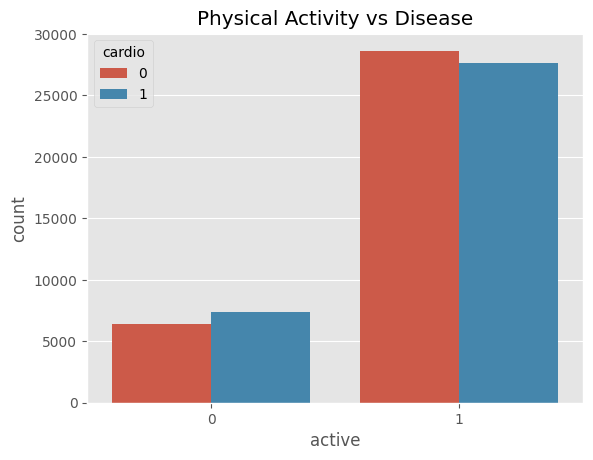

In [68]:
#Physical Activity Analysis
sns.countplot(
    x="active",
    hue="cardio",
    data=df
)

plt.title("Physical Activity vs Disease")

plt.show()

In [ ]:
#Correlation Analysis

In [69]:
corr = df.drop("id", axis=1).corr(numeric_only=True)

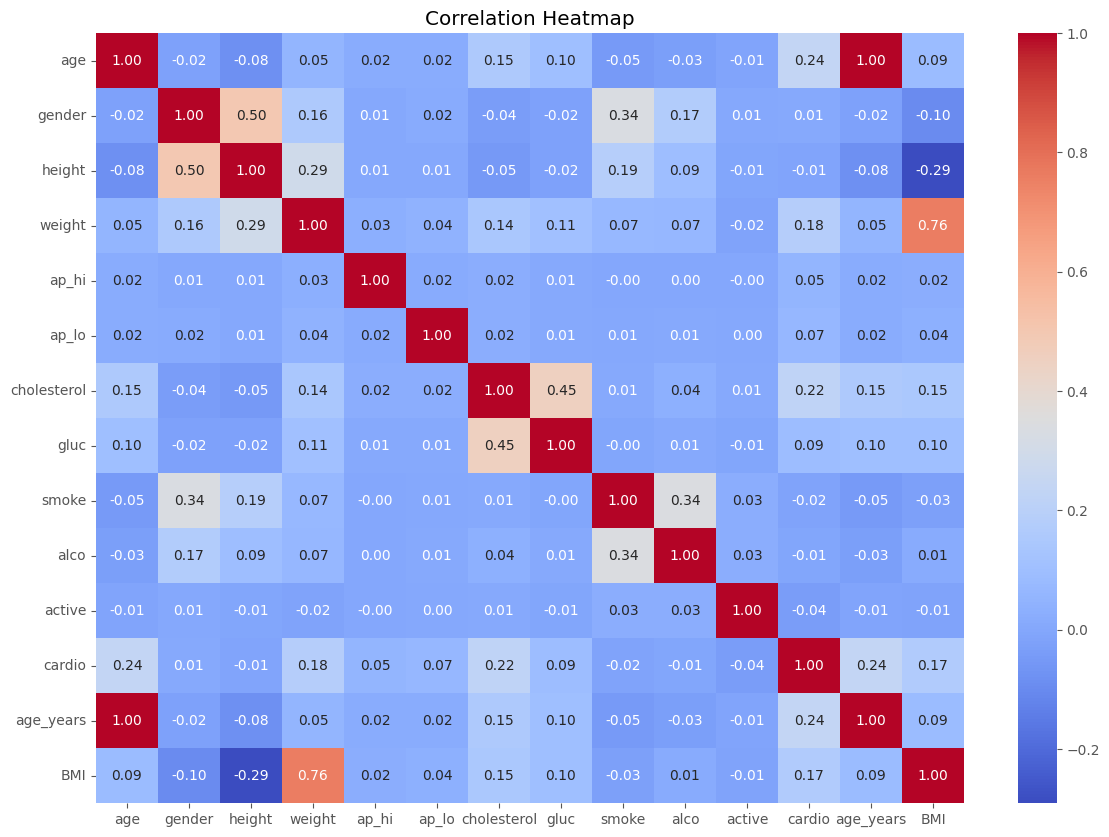

In [70]:
#HeatMap
plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()


In [88]:
plt.savefig("correlation_heatmap.png")

<Figure size 640x480 with 0 Axes>

In [71]:
#Most Important Risk Factors
corr["cardio"].sort_values(
    ascending=False
)

,cardio
cardio,1.000000
age,0.238159
age_years,0.237985
cholesterol,0.221147
weight,0.181660
BMI,0.165632
gluc,0.089307
ap_lo,0.065719
ap_hi,0.054475
gender,0.008109


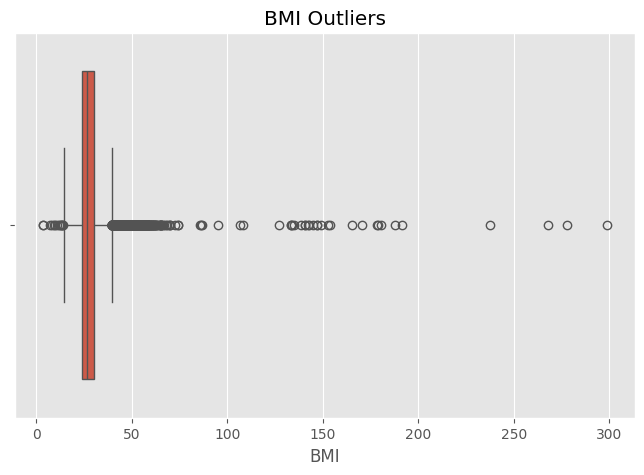

In [72]:
#Outlier Detection
plt.figure(figsize=(8,5))

sns.boxplot(x=df["BMI"])

plt.title("BMI Outliers")

plt.show()

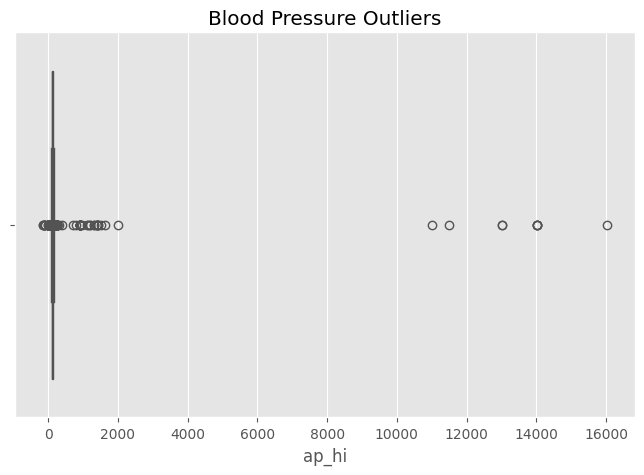

In [73]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["ap_hi"])

plt.title("Blood Pressure Outliers")

plt.show()

In [74]:
#Useful Filters
#Patients above age 60:
df[df["age_years"] > 60]
#High BMI:
df[df["BMI"] > 30]
#Disease Patients:
df[df["cardio"] == 1]
#Smokers with Disease:
df[
    (df["smoke"] == 1)
    &
    (df["cardio"] == 1)
]
#Inactive Patients:
df[df["active"] == 0]


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,BMI
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,51,23.507805
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,47,23.011177
5,8,21914,1,151,67.0,120,80,2,2,0,0,0,0,60,29.384676
9,14,19834,1,164,68.0,110,60,1,1,0,0,0,0,54,25.282570
12,18,14791,2,165,60.0,120,80,1,1,0,0,0,0,40,22.038567
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69970,99958,22572,2,173,103.0,140,80,3,1,1,1,0,1,61,34.414782
69980,99971,17727,2,167,69.0,110,80,1,1,0,1,0,0,48,24.740937
69985,99977,18194,1,156,102.0,130,80,1,1,0,1,0,1,49,41.913215
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1,52,31.353579


In [75]:
summary = pd.DataFrame({
    "Average Age": df.groupby("cardio")["age_years"].mean(),
    "Average BMI": df.groupby("cardio")["BMI"].mean(),
    "Average Systolic BP": df.groupby("cardio")["ap_hi"].mean(),
    "Average Cholesterol": df.groupby("cardio")["cholesterol"].mean(),
    "Average Glucose": df.groupby("cardio")["gluc"].mean()
})

summary.index = ["No Disease", "Disease"]

summary

,Average Age,Average BMI,Average Systolic BP,Average Cholesterol,Average Glucose
No Disease,51.231261,26.548175,120.432598,1.216527,1.175380
Disease,54.452014,28.566061,137.212042,1.517396,1.277595


In [77]:
#Machine Learning Model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [78]:
#Prepare Features and Target
X = df.drop(['cardio'], axis=1)
y = df['cardio']

In [79]:
print(X.shape)
print(y.shape)

(70000, 14)
(70000,)


In [ ]:
# Machine Learning Model

In [80]:
#Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [81]:
#Train Logistic Regression
model = LogisticRegression(max_iter=5000)

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=5000)

In [82]:
#Make Predictions
y_pred = model.predict(X_test)

In [ ]:
# Model Evaluation

In [83]:
#Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7227857142857143


[[5347 1641]
 [2240 4772]]


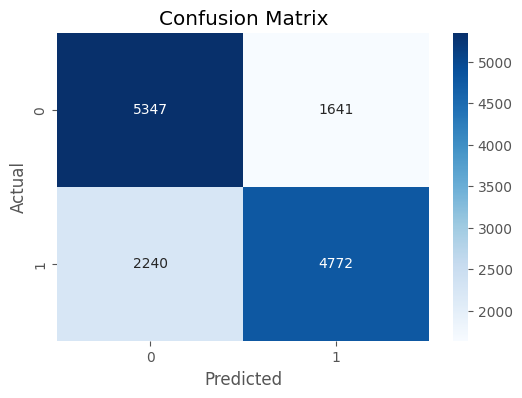

In [84]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()


In [85]:
#Classification Report
print(classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

           0       0.70      0.77      0.73      6988
           1       0.74      0.68      0.71      7012

    accuracy                           0.72     14000
   macro avg       0.72      0.72      0.72     14000
weighted avg       0.72      0.72      0.72     14000



In [86]:
#Feature Importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

importance = importance.sort_values(
    by='Coefficient',
    ascending=False
)

print(importance)

        Feature   Coefficient
7   cholesterol  5.146756e-01
2        gender  9.962334e-02
4        weight  5.768070e-02
12    age_years  5.174073e-02
5         ap_hi  3.659766e-02
6         ap_lo  3.001436e-04
0            id -2.477231e-07
1           age -2.831724e-06
3        height -5.477404e-02
13          BMI -1.102905e-01
8          gluc -1.123452e-01
9         smoke -1.444000e-01
10         alco -1.567062e-01
11       active -2.208681e-01


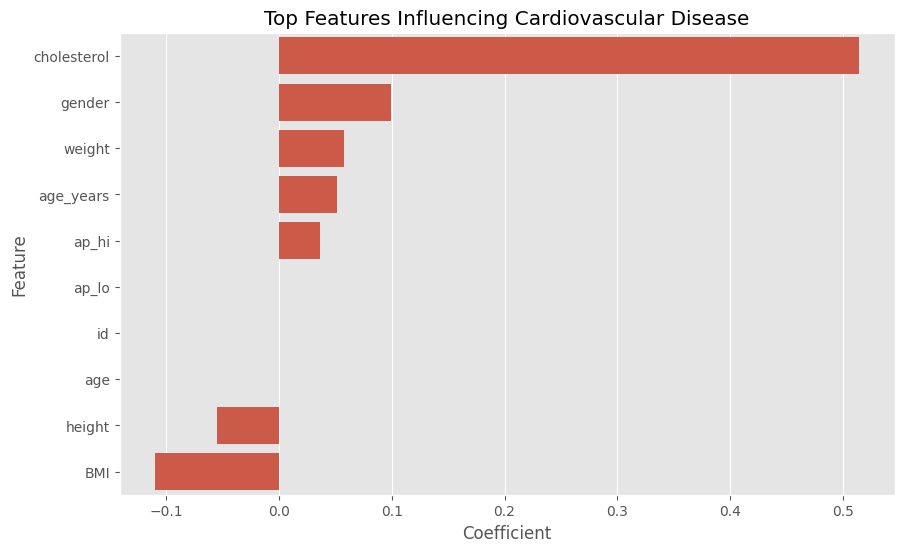

In [87]:
#Plot Top Features
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x='Coefficient',
    y='Feature'
)

plt.title(
    "Top Features Influencing Cardiovascular Disease"
)

plt.show()

In [ ]:
# Conclusion

The analysis revealed that blood pressure, age, BMI, cholesterol, and glucose levels are important cardiovascular disease risk factors. The Logistic Regression model achieved satisfactory predictive performance.